# 12. Clustering Methods: K-Means, Hierarchical, and Density-Based Ideas

In the previous notebook, we treated clustering as a practical segmentation workflow. Here we go one level deeper and compare **algorithm families**. That matters because clustering results are shaped by the assumptions built into the method: whether clusters are treated as compact balls around centroids, nested branches in a hierarchy, or dense regions separated by sparse space.

This is one of the central lessons of the clustering literature. Clustering is widely used to extract structure from unlabeled data, but no single method solves all clustering problems (Oyewole & Thopil, 2022). So the question is not “Which clustering algorithm is best?” The right question is “Which clustering assumptions match the geometry of the data and the decision use case?”

## Learning Objectives

By the end of this lecture, you should be able to:

1. explain the geometric assumptions behind k-means, hierarchical clustering, and DBSCAN,
2. recognize when a clustering method is mismatched to the structure of the data,
3. interpret dendrograms as multi-scale clustering summaries rather than decorative graphics,
4. understand why density-based methods can recover non-convex clusters and flag noise,
5. compare clustering outputs using internal diagnostics, external benchmarks, and decision usefulness,
6. choose a clustering family more deliberately for operational decision-science work.


## 1. Why Algorithm Families Matter

Clustering methods differ because they formalize “similarity” differently.

### K-Means

K-means is a **partitioning** method. We choose a number of clusters $K$, assign each observation $x_i$ to one cluster $c_i$, and minimize the within-cluster sum of squares:

$$
\min_{\{c_i\}, \{\mu_k\}} \sum_{i=1}^n \left\|x_i - \mu_{c_i}\right\|_2^2.
$$

This objective makes k-means most natural when clusters are compact, roughly convex, and well described by centroids. The method is popular because it is simple and fast, but it also depends on the chosen $K$ and on initialization (Kumar & Sahoo, 2014).

### Hierarchical Clustering

Agglomerative hierarchical clustering starts with each point as its own cluster, then repeatedly merges the two closest clusters. The result is a full **hierarchy of partitions**, summarized by a dendrogram (Murtagh & Contreras, 2017). The merge rule depends on a linkage criterion:

- **single linkage** uses the closest pair across clusters,
- **complete linkage** uses the farthest pair,
- **average linkage** uses average pairwise distance,
- **Ward linkage** merges the pair that causes the smallest increase in within-cluster variance.

For Ward linkage, the merge rule can be written as

$$
\Delta(A, B) = \text{SSE}(A \cup B) - \text{SSE}(A) - \text{SSE}(B),
$$

and the algorithm merges the pair with the smallest $\Delta(A, B)$.

### Density-Based Clustering

DBSCAN treats clusters as dense regions. A point $x_i$ is a **core point** if its $\varepsilon$-neighborhood contains at least `MinPts` observations:

$$
|N_{\varepsilon}(x_i)| \geq \text{MinPts}.
$$

Clusters are built from points that are density-reachable from core points, and points not assigned to any dense region are labeled as noise. Density-based methods are attractive because they can recover irregular shapes and isolate outliers, and DBSCAN does not require the number of clusters as an input (Bessrour et al., 2020).

### Evaluation Must Follow the Use Case

Cluster validation is also method-sensitive. Bolshakova and Azuaje (2003) emphasize that internal criteria such as silhouette, Dunn, and Davies-Bouldin capture compactness and separation, but they still leave open whether the resulting partition is the most useful one for the real task. In applied decision work, we therefore care about three layers at once:

1. **geometry**: do the clusters fit the shape of the data?
2. **stability**: do mild perturbations radically alter the result?
3. **actionability**: do the segments support different decisions, playbooks, or policies?

That is the organizing logic of this notebook.


In [1]:
# Section focus: Evaluation Must Follow the Use Case.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.


import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.cluster.hierarchy import dendrogram, linkage

from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.datasets import make_blobs, make_moons
from sklearn.decomposition import PCA
from sklearn.metrics import (
    adjusted_rand_score,
    davies_bouldin_score,
    normalized_mutual_info_score,
    silhouette_score,
)
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 140)
pd.set_option('display.max_colwidth', 120)
pd.options.display.float_format = '{:,.3f}'.format

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 15
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

rng = np.random.default_rng(2026)


## 2. Two Benchmark Geometries

Before we return to business-style tabular data, we begin with two controlled two-dimensional examples.

- A **compact blob dataset**, where the true clusters are roughly spherical and centroid-friendly.
- A **crescent-shaped dataset with injected outliers**, where the true structure is non-convex and noise is present.

These datasets are intentionally low-dimensional. They let us see the geometric bias of each algorithm before higher-dimensional business data hides that bias from view.


In [2]:
# Section focus: 2. Two Benchmark Geometries.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.


X_blobs, y_blobs = make_blobs(
    n_samples=900,
    centers=[(-2.2, -1.2), (0.1, 2.6), (2.3, -1.4)],
    cluster_std=[0.55, 0.75, 0.60],
    random_state=12,
)

X_moons, y_moons = make_moons(n_samples=900, noise=0.07, random_state=12)
moon_noise = rng.uniform(low=[-1.6, -1.0], high=[2.6, 1.6], size=(70, 2))
X_moons_noisy = np.vstack([X_moons, moon_noise])
y_moons_noisy = np.concatenate([y_moons, np.full(len(moon_noise), 2)])

dataset_overview = pd.DataFrame(
    [
        {
            'dataset': 'Compact blobs',
            'observations': len(X_blobs),
            'true_groups_or_classes': len(np.unique(y_blobs)),
            'shape_story': 'Well-separated, centroid-friendly groups',
        },
        {
            'dataset': 'Moons plus outliers',
            'observations': len(X_moons_noisy),
            'true_groups_or_classes': len(np.unique(y_moons_noisy)),
            'shape_story': 'Curved structure with injected noise points',
        },
    ]
)

dataset_overview


,dataset,observations,true_groups_or_classes,shape_story
0,Compact blobs,900,3,"Well-separated, centroid-friendly groups"
1,Moons plus outliers,970,3,Curved structure with injected noise points


Two Benchmark Geometries gives a checkpoint for the decision workflow. The result becomes useful when it sharpens the next action.


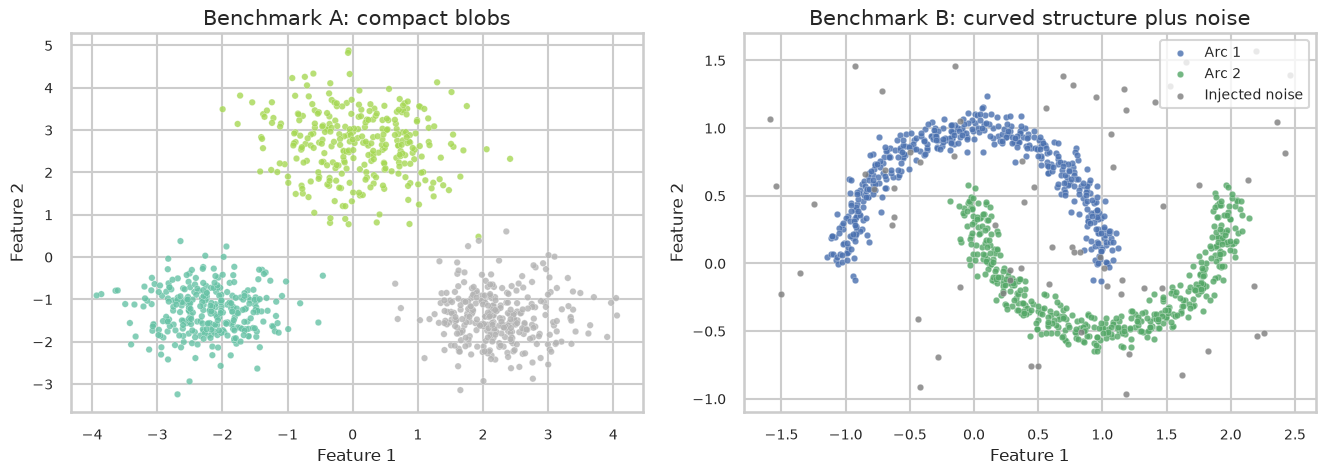

In [3]:
# Section focus: 2. Two Benchmark Geometries.
# The code below keeps the calculation explicit so each intermediate step can be inspected.


fig, axes = plt.subplots(1, 2, figsize=(13.6, 5.1))

axes[0].scatter(X_blobs[:, 0], X_blobs[:, 1], c=y_blobs, cmap='Set2', s=22, alpha=0.8, edgecolor='white', linewidth=0.2)
axes[0].set_title('Benchmark A: compact blobs')
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')

moon_palette = {0: '#4c72b0', 1: '#55a868', 2: '#7f7f7f'}
moon_labels = {0: 'Arc 1', 1: 'Arc 2', 2: 'Injected noise'}
for cls in [0, 1, 2]:
    subset = X_moons_noisy[y_moons_noisy == cls]
    axes[1].scatter(
        subset[:, 0],
        subset[:, 1],
        color=moon_palette[cls],
        label=moon_labels[cls],
        s=22,
        alpha=0.82,
        edgecolor='white',
        linewidth=0.2,
    )
axes[1].set_title('Benchmark B: curved structure plus noise')
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')
axes[1].legend(loc='upper right', frameon=True)

plt.tight_layout()


The Two Benchmark Geometries result matters when it changes the next move. The analysis should end with a clearer modeling, diagnostic, or governance move.


### Discussion of the Benchmark Geometries

These two datasets are useful because they separate two different clustering challenges.

In the blob dataset, cluster membership is well captured by proximity to centroids. That is the environment where partitioning methods such as k-means tend to look excellent.

In the moon dataset, the real groups are curved rather than convex, and the extra noise points are not meant to belong anywhere. This is the kind of situation where compactness-based clustering can become misleading and density-based logic can become more attractive.


## 3. K-Means as a Centroid-Based Partitioning Method

K-means is often the first clustering method analysts reach for because it is fast and interpretable. But the very objective that makes it simple also constrains what it can represent.

Because k-means partitions space by nearest centroids, its clusters behave like Voronoi cells. That works well when the data really do look like compact islands around representative centers. It works much less well when the structure is elongated, crescent-shaped, or separated by density rather than centroid distance.

We will fit k-means to both benchmark datasets and compare the results to the known data-generating labels.


In [4]:
# Section focus: 3. K-Means as a Centroid-Based Partitioning Method.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.


def evaluate_clustering(X, labels, truth=None):
    """Evaluate clustering for the 12. Clustering Methods: K-Means, Hierarchical, and Density-Based Ideas decision workflow.
    
    Parameters
    ----------
    X : object
        Feature matrix used for fitting, prediction, or diagnostics.
    labels : object
        Observed or assigned labels used for evaluation.
    truth : object
        The truth setting that controls the clustering calculation in this notebook.
    
    Returns
    -------
    object
        Dictionary or table of metrics used to compare model behavior.
    """
    labels = np.asarray(labels)
    non_noise = labels != -1
    cluster_labels = labels[non_noise]
    unique_clusters = np.unique(cluster_labels) if non_noise.any() else np.array([])

    result = {
        'clusters_found': int(len(unique_clusters)),
        'noise_share': 1.0 - float(non_noise.mean()),
        'smallest_cluster_share': np.nan,
        'largest_cluster_share': np.nan,
        'silhouette_non_noise': np.nan,
        'davies_bouldin_non_noise': np.nan,
        'ARI_vs_truth': np.nan,
        'NMI_vs_truth': np.nan,
    }

    if len(unique_clusters) >= 1:
        counts = pd.Series(cluster_labels).value_counts(normalize=True)
        result['smallest_cluster_share'] = float(counts.min())
        result['largest_cluster_share'] = float(counts.max())

    if len(unique_clusters) >= 2 and non_noise.sum() > 1:
        result['silhouette_non_noise'] = float(silhouette_score(X[non_noise], cluster_labels))
        result['davies_bouldin_non_noise'] = float(davies_bouldin_score(X[non_noise], cluster_labels))

    if truth is not None:
        result['ARI_vs_truth'] = float(adjusted_rand_score(truth, labels))
        result['NMI_vs_truth'] = float(normalized_mutual_info_score(truth, labels))

    return result


def plot_clusters(ax, X, labels, title, centers=None):
    """Draw the clusters figure for the 12. Clustering Methods: K-Means, Hierarchical, and Density-Based Ideas analysis.
    
    Parameters
    ----------
    ax : object
        Matplotlib axis on which the plot is drawn.
    X : object
        Feature matrix used for fitting, prediction, or diagnostics.
    labels : object
        Observed or assigned labels used for evaluation.
    title : object
        Title used to label the displayed result.
    centers : object
        The centers setting that controls the clusters calculation in this notebook.
    
    Returns
    -------
    object
        None. The function updates a plot, display object, or notebook state as its side effect.
    """
    labels = np.asarray(labels)
    unique_labels = np.unique(labels)
    palette = sns.color_palette('tab10', n_colors=max(3, len(unique_labels)))
    color_map = {}
    next_idx = 0
    for lab in unique_labels:
        if lab == -1:
            color_map[lab] = '#b8b8b8'
        else:
            color_map[lab] = palette[next_idx % len(palette)]
            next_idx += 1

    for lab in unique_labels:
        subset = X[labels == lab]
        ax.scatter(
            subset[:, 0],
            subset[:, 1],
            s=24,
            alpha=0.82,
            color=color_map[lab],
            edgecolor='white',
            linewidth=0.2,
            label='Noise' if lab == -1 else f'Cluster {lab}',
        )

    if centers is not None:
        ax.scatter(
            centers[:, 0],
            centers[:, 1],
            marker='X',
            s=220,
            color='black',
            edgecolor='white',
            linewidth=0.8,
            label='Centroids',
        )

    ax.set_title(title)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')


kmeans_blobs = KMeans(n_clusters=3, n_init=25, random_state=12).fit(X_blobs)
kmeans_moons = KMeans(n_clusters=2, n_init=25, random_state=12).fit(X_moons_noisy)

kmeans_results = pd.DataFrame(
    [
        {'dataset': 'Compact blobs', 'method': 'K-means (K=3)', **evaluate_clustering(X_blobs, kmeans_blobs.labels_, y_blobs)},
        {'dataset': 'Moons plus outliers', 'method': 'K-means (K=2)', **evaluate_clustering(X_moons_noisy, kmeans_moons.labels_, y_moons_noisy)},
    ]
)

kmeans_results


,dataset,method,clusters_found,noise_share,smallest_cluster_share,largest_cluster_share,silhouette_non_noise,davies_bouldin_non_noise,ARI_vs_truth,NMI_vs_truth
0,Compact blobs,K-means (K=3),3,0.000,0.332,0.334,0.737,0.362,0.997,0.993
1,Moons plus outliers,K-means (K=2),2,0.000,0.496,0.504,0.478,0.798,0.205,0.145


Read K-Means as a Centroid-Based Partitioning Method as a decision checkpoint. The point is to identify the part of the result with operational consequence.


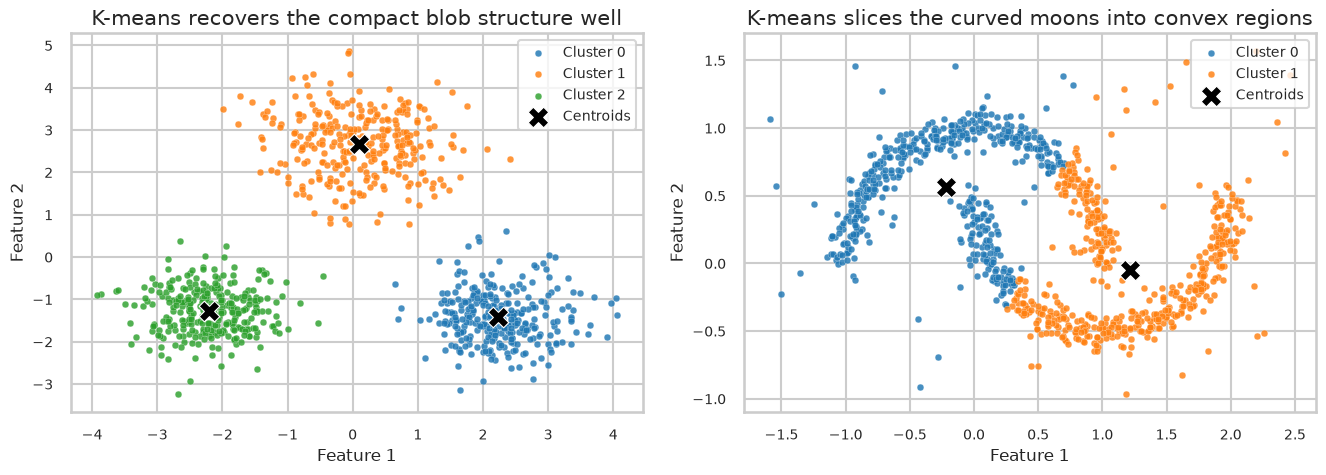

In [5]:

fig, axes = plt.subplots(1, 2, figsize=(13.6, 5.1))

plot_clusters(
    axes[0],
    X_blobs,
    kmeans_blobs.labels_,
    title='K-means recovers the compact blob structure well',
    centers=kmeans_blobs.cluster_centers_,
)
axes[0].legend(loc='upper right', frameon=True)

plot_clusters(
    axes[1],
    X_moons_noisy,
    kmeans_moons.labels_,
    title='K-means slices the curved moons into convex regions',
    centers=kmeans_moons.cluster_centers_,
)
axes[1].legend(loc='upper right', frameon=True)

plt.tight_layout()


The practical question in K-Means as a Centroid-Based Partitioning Method is simple. What would this result make the analyst do differently?


### Discussion of the K-Means Results

The contrast is sharp.

On the compact blob dataset, k-means is nearly perfect. The ARI is extremely high, the silhouette is strong, and the partition matches the intuitive geometry of the data.

On the moon dataset, the silhouette can still look respectable, but the clustering itself is conceptually wrong. The algorithm draws a boundary based on centroid distance, so it cuts across the curved structure rather than following it. This is an important warning sign for practice: **a decent internal score does not guarantee that the algorithm has recovered the meaningful structure**.


## 4. Hierarchical Clustering and the Meaning of Linkage

Hierarchical clustering answers a different question from k-means. Instead of asking for one partition immediately, it builds a nested family of partitions.

That is attractive in decision work for at least two reasons:

1. we may not know the right granularity in advance,
2. the dendrogram can reveal whether the data contain a few broad regimes that later split into finer operational subtypes.

But hierarchical clustering is not a single method. The linkage rule matters a lot. Murtagh and Contreras (2017) emphasize that hierarchical clustering outputs a hierarchy summarized by a dendrogram, and that linkage choices such as single, complete, average, and Ward produce meaningfully different behavior.

We will compare several linkage rules on the moon dataset, then inspect a Ward dendrogram on a small sample.


In [6]:

linkage_methods = ['single', 'complete', 'ward']
hierarchical_labels = {}

hierarchical_results = []
for method in linkage_methods:
    model = AgglomerativeClustering(n_clusters=2, linkage=method)
    labels = model.fit_predict(X_moons_noisy)
    hierarchical_labels[method] = labels
    hierarchical_results.append(
        {'linkage': method.title(), **evaluate_clustering(X_moons_noisy, labels, y_moons_noisy)}
    )

hierarchical_results = pd.DataFrame(hierarchical_results)
hierarchical_results


,linkage,clusters_found,noise_share,smallest_cluster_share,largest_cluster_share,silhouette_non_noise,davies_bouldin_non_noise,ARI_vs_truth,NMI_vs_truth
0,Single,2,0.000,0.001,0.999,0.351,0.419,0.003,0.006
1,Complete,2,0.000,0.285,0.715,0.428,0.771,0.272,0.316
2,Ward,2,0.000,0.337,0.663,0.429,0.824,0.391,0.397


This table is the quantitative checkpoint for Hierarchical Clustering and the Meaning of Linkage. Compare the rows by asking which one would change model choice, threshold setting, review priority, or guardrail design.


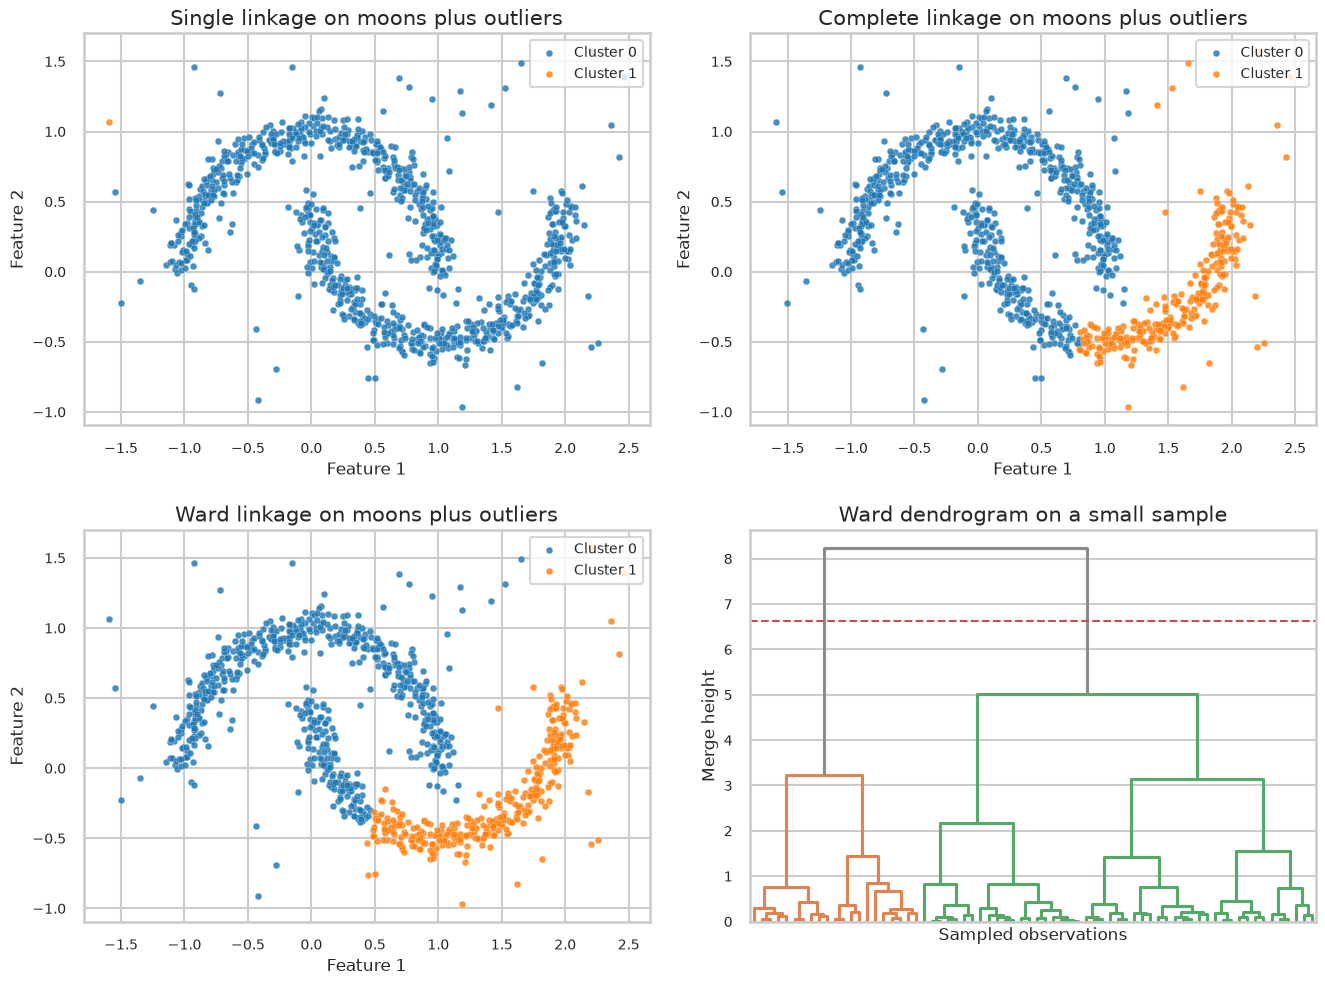

In [7]:
# Section focus: 4. Hierarchical Clustering and the Meaning of Linkage.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.


fig, axes = plt.subplots(2, 2, figsize=(13.6, 10.2))
axes = axes.ravel()

for ax, method in zip(axes[:3], linkage_methods):
    plot_clusters(
        ax,
        X_moons_noisy,
        hierarchical_labels[method],
        title=f'{method.title()} linkage on moons plus outliers',
    )
    ax.legend(loc='upper right', frameon=True)

sample_idx = rng.choice(len(X_moons_noisy), size=70, replace=False)
X_sample = X_moons_noisy[sample_idx]
Z_ward = linkage(X_sample, method='ward')
cut_height = 0.5 * (Z_ward[-2, 2] + Z_ward[-1, 2])

dendrogram(
    Z_ward,
    ax=axes[3],
    no_labels=True,
    color_threshold=cut_height,
    above_threshold_color='0.55',
)
axes[3].axhline(cut_height, linestyle='--', color='#c44e52', linewidth=1.5)
axes[3].set_title('Ward dendrogram on a small sample')
axes[3].set_xlabel('Sampled observations')
axes[3].set_ylabel('Merge height')

plt.tight_layout()


Use the Hierarchical Clustering and the Meaning of Linkage output to decide what the analysis should do next. Look for the signal that would change a concrete operating choice.


### Discussion of the Hierarchical Results

The hierarchical comparison makes two lessons visible.

First, **linkage is not a minor tuning option**. Single linkage is highly vulnerable to chaining: points can form long bridges that merge clusters too eagerly. Complete linkage is more conservative, and Ward linkage tends to favor compact partitions because it tries to control within-cluster variance.

Second, the dendrogram is useful precisely because it shows clustering at multiple scales. A horizontal cut through the tree produces a flat partition, but the full tree tells us whether clusters are merging cleanly or through ambiguous bridges. That can be valuable when analysts want both broad segmentation and finer nested subgroups.

The downside is computational. Hierarchical clustering is often much heavier than k-means, especially as sample size grows, which is one reason Murtagh and Contreras (2017) discuss algorithmic improvements and the practical cost of dendrogram construction.


## 5. Density-Based Clustering with DBSCAN

DBSCAN is organized around local density rather than centroids or merge trees. That changes the kinds of structures it can recover.

Its appeal is straightforward:

- it can find irregularly shaped clusters,
- it can label isolated observations as noise,
- it does not require the number of clusters as an explicit input.

Its cost is also straightforward:

- the parameters $\varepsilon$ and `MinPts` matter a lot,
- varying local density can make one global setting unstable,
- internal scores such as silhouette can look worse even when the clustering is conceptually more faithful to the real geometry.

We will sweep several $\varepsilon$ values on the moon dataset to make that tradeoff visible.


In [8]:

dbscan_settings = [
    {'label': 'Tight density', 'eps': 0.11, 'min_samples': 8},
    {'label': 'Balanced density', 'eps': 0.14, 'min_samples': 8},
    {'label': 'Loose density', 'eps': 0.20, 'min_samples': 8},
]

dbscan_runs = {}
dbscan_results = []
for cfg in dbscan_settings:
    labels = DBSCAN(eps=cfg['eps'], min_samples=cfg['min_samples']).fit_predict(X_moons_noisy)
    dbscan_runs[cfg['label']] = labels
    dbscan_results.append(
        {
            'setting': cfg['label'],
            'eps': cfg['eps'],
            'min_samples': cfg['min_samples'],
            **evaluate_clustering(X_moons_noisy, labels, y_moons_noisy),
        }
    )

dbscan_results = pd.DataFrame(dbscan_results)
dbscan_results


,setting,eps,min_samples,clusters_found,noise_share,smallest_cluster_share,largest_cluster_share,silhouette_non_noise,davies_bouldin_non_noise,ARI_vs_truth,NMI_vs_truth
0,Tight density,0.110,8,2,0.053,0.498,0.502,0.331,1.153,0.946,0.889
1,Balanced density,0.140,8,2,0.046,0.498,0.502,0.329,1.160,0.942,0.886
2,Loose density,0.200,8,1,0.033,1.000,1.000,NaN,NaN,0.091,0.182


Use this table as a compact audit record. It shows which cases, segments, models, or assumptions carry the most weight in Density-Based Clustering with DBSCAN. A standout row should trigger a signal-versus-artifact check.


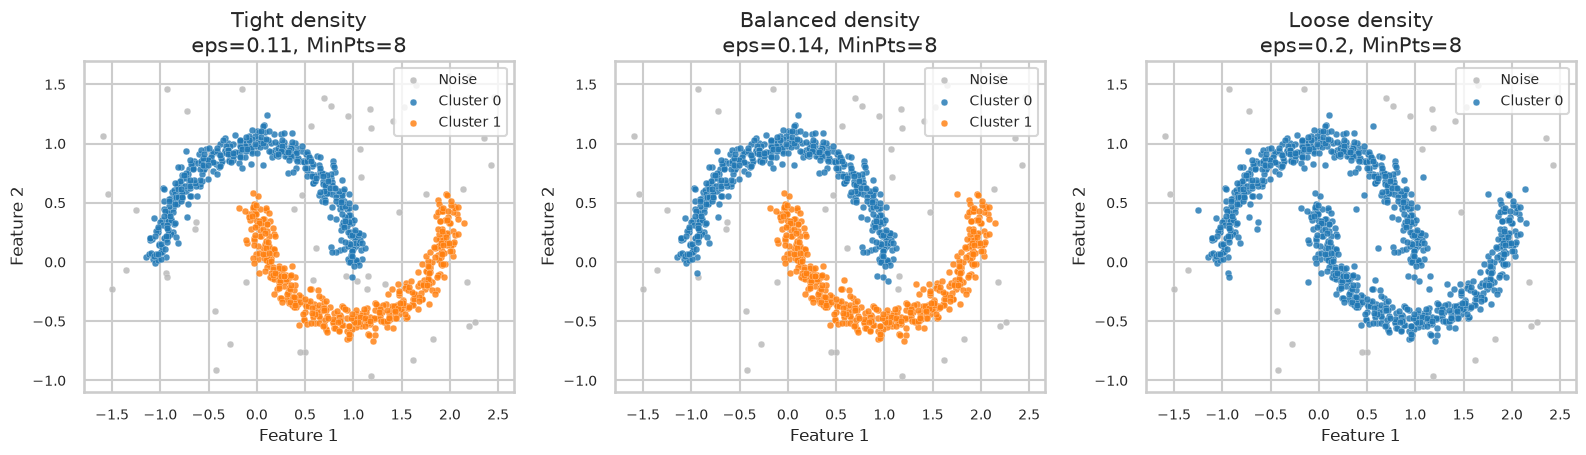

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16.2, 4.9))

for ax, cfg in zip(axes, dbscan_settings):
    labels = dbscan_runs[cfg['label']]
    plot_clusters(
        ax,
        X_moons_noisy,
        labels,
        title=f"{cfg['label']}\neps={cfg['eps']}, MinPts={cfg['min_samples']}",
    )
    ax.legend(loc='upper right', frameon=True)

plt.tight_layout()

The plot matters because it shows structure that a single summary number can hide. For Density-Based Clustering with DBSCAN, look for where groups separate, where curves bend, or where the tails behave differently. Those features should shape the next choice about model class, threshold, monitoring, or human review.


### Discussion of the DBSCAN Results

DBSCAN behaves differently from the earlier methods in exactly the way we would hope.

With a reasonable density setting, it recovers the curved moon structure very well and correctly isolates many of the injected outliers as noise. But the parameter sweep also shows why density-based clustering can feel fragile in practice. If $\varepsilon$ is too small, too many observations become noise; if it is too large, separate dense regions collapse into one giant cluster.

There is also a nice methodological twist here. The DBSCAN solution can have a **better ARI and worse silhouette** than k-means on the same data. That is not a contradiction. It simply means that silhouette prefers compact separated groups, whereas the true data-generating structure is curved and density-defined.


## 6. Comparing Methods on an Operational Portfolio Dataset

Controlled geometry is helpful, but decision scientists rarely cluster crescent moons for a living. We therefore return to a more realistic tabular setting: a synthetic portfolio of marketplace accounts with latent operating regimes.

This simulator mirrors the previous notebook. The hidden regimes differ in account scale, volatility, self-service behavior, friction, and operational burden. We also simulate downstream outcomes such as breach risk and expansion so that we can judge whether different clustering methods produce partitions that separate future operational behavior.

To isolate the effect of the algorithm family, we will hold the target segmentation granularity fixed at **five groups** for k-means and Ward clustering, then compare them with a DBSCAN solution that is free to discover a different number of dense regions.


In [10]:
# Section focus: 6. Comparing Methods on an Operational Portfolio Dataset.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.


def clip_normal(mean, sd, low, high, n, rng):
    """Carry out the clip normal step used in the 12. Clustering Methods: K-Means, Hierarchical, and Density-Based Ideas workflow.
    
    Parameters
    ----------
    mean : object
        The mean setting that controls the clip normal calculation in this notebook.
    sd : object
        The sd setting that controls the clip normal calculation in this notebook.
    low : object
        Lower value used in a range, interval, or simulation setting.
    high : object
        Upper value used in a range, interval, or simulation setting.
    n : object
        Number of observations or simulation units used by the calculation.
    rng : object
        Random number generator used to make the simulation reproducible.
    
    Returns
    -------
    object
        Array-like values produced by the calculation.
    """
    return np.clip(rng.normal(mean, sd, size=n), low, high)


def simulate_unsupervised_accounts(n=4200, random_state=2026):
    """Create a simulated unsupervised accounts data set for the 12. Clustering Methods: K-Means, Hierarchical, and Density-Based Ideas case study.
    
    Parameters
    ----------
    n : object
        Number of observations or simulation units used by the calculation.
    random_state : object
        Random seed or generator control used to make results reproducible.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    rng = np.random.default_rng(random_state)

    segment_names = [
        'Global enterprise',
        'Growth assisted',
        'Automation-first SMB',
        'Seasonal volatile',
        'Distressed friction',
    ]
    probs = np.array([0.15, 0.27, 0.28, 0.16, 0.14])
    segments = rng.choice(segment_names, size=n, p=probs)

    rows = []
    for seg in segments:
        if seg == 'Global enterprise':
            monthly_gmv_log = clip_normal(12.2, 0.45, 10.8, 13.6, 1, rng)[0]
            order_volatility = clip_normal(0.21, 0.08, 0.05, 0.55, 1, rng)[0]
            self_service_share = clip_normal(0.55, 0.10, 0.18, 0.88, 1, rng)[0]
            support_touches_30d = clip_normal(7.0, 2.0, 2.0, 16.0, 1, rng)[0]
            incident_rate_90d = clip_normal(0.11, 0.05, 0.01, 0.28, 1, rng)[0]
            feature_adoption_score = clip_normal(0.86, 0.08, 0.45, 1.0, 1, rng)[0]
            response_delay_hours = clip_normal(6.5, 2.0, 1.0, 16.0, 1, rng)[0]
            payment_friction_rate = clip_normal(0.05, 0.03, 0.0, 0.20, 1, rng)[0]
            cross_border_share = clip_normal(0.63, 0.16, 0.15, 0.95, 1, rng)[0]
            ad_spend_share = clip_normal(0.17, 0.08, 0.0, 0.45, 1, rng)[0]
            dispute_rate = clip_normal(0.020, 0.010, 0.001, 0.070, 1, rng)[0]
            tenure_months = clip_normal(52, 14, 12, 96, 1, rng)[0]
        elif seg == 'Growth assisted':
            monthly_gmv_log = clip_normal(11.1, 0.40, 9.9, 12.3, 1, rng)[0]
            order_volatility = clip_normal(0.28, 0.10, 0.06, 0.65, 1, rng)[0]
            self_service_share = clip_normal(0.42, 0.11, 0.10, 0.78, 1, rng)[0]
            support_touches_30d = clip_normal(8.7, 2.4, 2.5, 18.0, 1, rng)[0]
            incident_rate_90d = clip_normal(0.15, 0.06, 0.02, 0.34, 1, rng)[0]
            feature_adoption_score = clip_normal(0.67, 0.10, 0.25, 0.95, 1, rng)[0]
            response_delay_hours = clip_normal(10.4, 2.8, 2.0, 22.0, 1, rng)[0]
            payment_friction_rate = clip_normal(0.10, 0.05, 0.01, 0.26, 1, rng)[0]
            cross_border_share = clip_normal(0.34, 0.14, 0.0, 0.75, 1, rng)[0]
            ad_spend_share = clip_normal(0.31, 0.11, 0.03, 0.68, 1, rng)[0]
            dispute_rate = clip_normal(0.041, 0.018, 0.003, 0.110, 1, rng)[0]
            tenure_months = clip_normal(24, 9, 4, 60, 1, rng)[0]
        elif seg == 'Automation-first SMB':
            monthly_gmv_log = clip_normal(9.9, 0.35, 8.9, 11.0, 1, rng)[0]
            order_volatility = clip_normal(0.18, 0.07, 0.03, 0.42, 1, rng)[0]
            self_service_share = clip_normal(0.82, 0.08, 0.45, 0.98, 1, rng)[0]
            support_touches_30d = clip_normal(2.7, 1.2, 0.0, 8.0, 1, rng)[0]
            incident_rate_90d = clip_normal(0.07, 0.04, 0.0, 0.20, 1, rng)[0]
            feature_adoption_score = clip_normal(0.58, 0.11, 0.15, 0.85, 1, rng)[0]
            response_delay_hours = clip_normal(7.8, 2.4, 1.0, 18.0, 1, rng)[0]
            payment_friction_rate = clip_normal(0.07, 0.04, 0.0, 0.20, 1, rng)[0]
            cross_border_share = clip_normal(0.12, 0.09, 0.0, 0.45, 1, rng)[0]
            ad_spend_share = clip_normal(0.10, 0.07, 0.0, 0.32, 1, rng)[0]
            dispute_rate = clip_normal(0.018, 0.010, 0.0, 0.060, 1, rng)[0]
            tenure_months = clip_normal(18, 7, 2, 45, 1, rng)[0]
        elif seg == 'Seasonal volatile':
            monthly_gmv_log = clip_normal(10.7, 0.38, 9.5, 11.9, 1, rng)[0]
            order_volatility = clip_normal(0.48, 0.11, 0.18, 0.88, 1, rng)[0]
            self_service_share = clip_normal(0.37, 0.11, 0.08, 0.74, 1, rng)[0]
            support_touches_30d = clip_normal(6.8, 2.1, 1.5, 15.5, 1, rng)[0]
            incident_rate_90d = clip_normal(0.19, 0.06, 0.04, 0.36, 1, rng)[0]
            feature_adoption_score = clip_normal(0.53, 0.10, 0.12, 0.82, 1, rng)[0]
            response_delay_hours = clip_normal(12.8, 3.0, 3.0, 24.0, 1, rng)[0]
            payment_friction_rate = clip_normal(0.11, 0.05, 0.01, 0.28, 1, rng)[0]
            cross_border_share = clip_normal(0.24, 0.12, 0.0, 0.64, 1, rng)[0]
            ad_spend_share = clip_normal(0.43, 0.12, 0.08, 0.82, 1, rng)[0]
            dispute_rate = clip_normal(0.052, 0.018, 0.010, 0.130, 1, rng)[0]
            tenure_months = clip_normal(22, 8, 3, 48, 1, rng)[0]
        else:
            monthly_gmv_log = clip_normal(10.1, 0.42, 8.8, 11.5, 1, rng)[0]
            order_volatility = clip_normal(0.35, 0.10, 0.10, 0.72, 1, rng)[0]
            self_service_share = clip_normal(0.24, 0.09, 0.02, 0.58, 1, rng)[0]
            support_touches_30d = clip_normal(10.6, 2.6, 3.0, 20.0, 1, rng)[0]
            incident_rate_90d = clip_normal(0.27, 0.06, 0.08, 0.45, 1, rng)[0]
            feature_adoption_score = clip_normal(0.31, 0.10, 0.02, 0.68, 1, rng)[0]
            response_delay_hours = clip_normal(18.8, 3.5, 8.0, 30.0, 1, rng)[0]
            payment_friction_rate = clip_normal(0.32, 0.08, 0.10, 0.55, 1, rng)[0]
            cross_border_share = clip_normal(0.18, 0.10, 0.0, 0.55, 1, rng)[0]
            ad_spend_share = clip_normal(0.19, 0.09, 0.0, 0.50, 1, rng)[0]
            dispute_rate = clip_normal(0.093, 0.020, 0.030, 0.180, 1, rng)[0]
            tenure_months = clip_normal(14, 6, 1, 36, 1, rng)[0]

        logit_breach = (
            -5.9
            + 0.18 * support_touches_30d
            + 5.4 * payment_friction_rate
            + 0.10 * response_delay_hours
            + 2.4 * incident_rate_90d
            - 2.2 * self_service_share
            - 0.55 * feature_adoption_score
            + 0.08 * order_volatility
        )
        breach_next_month = rng.binomial(1, 1 / (1 + np.exp(-logit_breach)))

        logit_expansion = (
            -1.1
            + 0.72 * feature_adoption_score
            + 0.55 * np.maximum(monthly_gmv_log - 10.5, 0)
            + 0.35 * cross_border_share
            - 1.0 * payment_friction_rate
            - 0.04 * response_delay_hours
        )
        expansion_next_quarter = rng.binomial(1, 1 / (1 + np.exp(-logit_expansion)))

        rows.append(
            {
                'true_segment': seg,
                'monthly_gmv_log': monthly_gmv_log,
                'order_volatility': order_volatility,
                'self_service_share': self_service_share,
                'support_touches_30d': support_touches_30d,
                'incident_rate_90d': incident_rate_90d,
                'feature_adoption_score': feature_adoption_score,
                'response_delay_hours': response_delay_hours,
                'payment_friction_rate': payment_friction_rate,
                'cross_border_share': cross_border_share,
                'ad_spend_share': ad_spend_share,
                'dispute_rate': dispute_rate,
                'tenure_months': tenure_months,
                'breach_next_month': breach_next_month,
                'expansion_next_quarter': expansion_next_quarter,
            }
        )

    return pd.DataFrame(rows)


df_portfolio = simulate_unsupervised_accounts()
feature_cols = [
    'monthly_gmv_log',
    'order_volatility',
    'self_service_share',
    'support_touches_30d',
    'incident_rate_90d',
    'feature_adoption_score',
    'response_delay_hours',
    'payment_friction_rate',
    'cross_border_share',
    'ad_spend_share',
    'dispute_rate',
    'tenure_months',
]

portfolio_overview = pd.DataFrame(
    [
        {
            'accounts': len(df_portfolio),
            'hidden_regimes': df_portfolio['true_segment'].nunique(),
            'breach_rate': df_portfolio['breach_next_month'].mean(),
            'expansion_rate': df_portfolio['expansion_next_quarter'].mean(),
            'avg_self_service_share': df_portfolio['self_service_share'].mean(),
            'avg_order_volatility': df_portfolio['order_volatility'].mean(),
        }
    ]
)

portfolio_overview


,accounts,hidden_regimes,breach_rate,expansion_rate,avg_self_service_share,avg_order_volatility
0,4200,5,0.076,0.316,0.516,0.284


In Comparing Methods on an Operational Portfolio Dataset, the point of the output is practical. A good output makes the next decision easier to defend.


In [11]:
# Section focus: 6. Comparing Methods on an Operational Portfolio Dataset.
# The code below keeps the calculation explicit so each intermediate step can be inspected.


X_portfolio = StandardScaler().fit_transform(df_portfolio[feature_cols])
truth_portfolio = df_portfolio['true_segment'].to_numpy()

portfolio_methods = {
    'K-means (K=5)': KMeans(n_clusters=5, n_init=25, random_state=12).fit_predict(X_portfolio),
    'Ward hierarchical (K=5)': AgglomerativeClustering(n_clusters=5, linkage='ward').fit_predict(X_portfolio),
    'DBSCAN (eps=1.65, MinPts=35)': DBSCAN(eps=1.65, min_samples=35).fit_predict(X_portfolio),
}

comparison_rows = []
for method_name, labels in portfolio_methods.items():
    metrics = evaluate_clustering(X_portfolio, labels, truth_portfolio)
    analysis_frame = df_portfolio.assign(cluster=labels)
    usable = analysis_frame.loc[analysis_frame['cluster'] != -1]
    if usable['cluster'].nunique() >= 1:
        breach_rates = usable.groupby('cluster')['breach_next_month'].mean()
        expansion_rates = usable.groupby('cluster')['expansion_next_quarter'].mean()
        metrics['breach_rate_range'] = float(breach_rates.max() - breach_rates.min())
        metrics['expansion_rate_range'] = float(expansion_rates.max() - expansion_rates.min())
    else:
        metrics['breach_rate_range'] = np.nan
        metrics['expansion_rate_range'] = np.nan
    comparison_rows.append({'method': method_name, **metrics})

portfolio_comparison = pd.DataFrame(comparison_rows)
portfolio_comparison


,method,clusters_found,noise_share,smallest_cluster_share,largest_cluster_share,silhouette_non_noise,davies_bouldin_non_noise,ARI_vs_truth,NMI_vs_truth,breach_rate_range,expansion_rate_range
0,K-means (K=5),5,0.000,0.139,0.280,0.336,1.373,0.935,0.930,0.427,0.438
1,Ward hierarchical (K=5),5,0.000,0.140,0.280,0.331,1.417,0.908,0.910,0.426,0.434
2,"DBSCAN (eps=1.65, MinPts=35)",3,0.316,0.062,0.529,0.389,0.988,0.458,0.564,0.346,0.229


Comparing Methods on an Operational Portfolio Dataset gives a checkpoint for the decision workflow. The relevant pattern is the one with operational consequences.


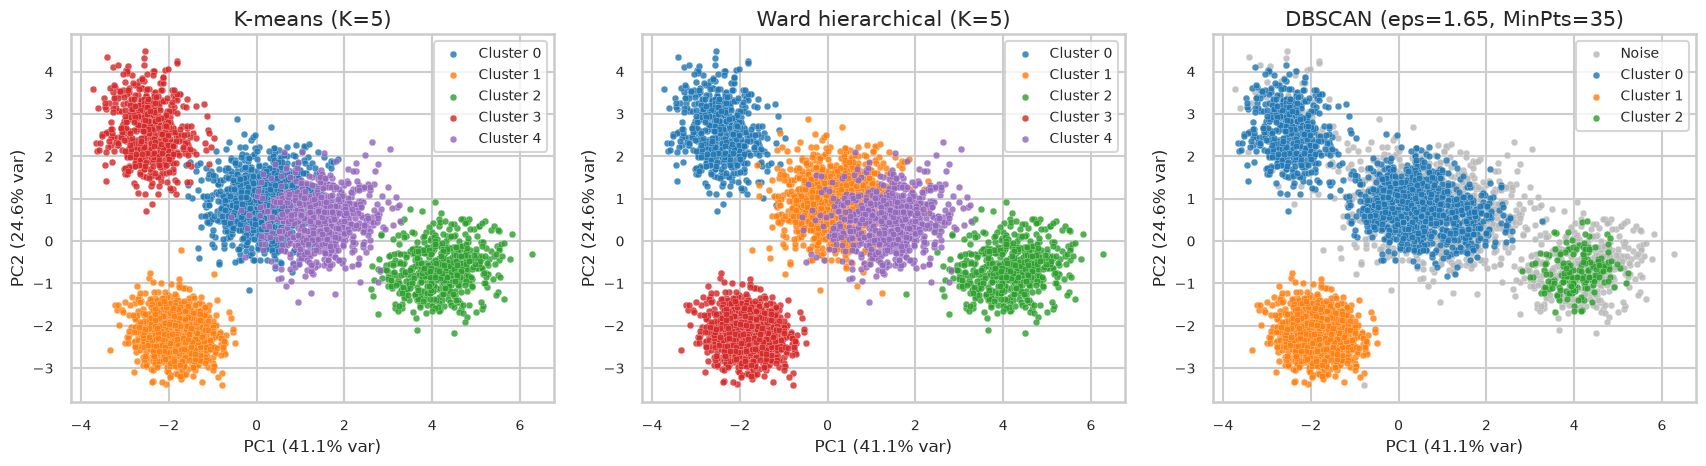

In [12]:

pca = PCA(n_components=2, random_state=12)
X_portfolio_pca = pca.fit_transform(X_portfolio)

fig, axes = plt.subplots(1, 3, figsize=(17.4, 5.0))

for ax, (method_name, labels) in zip(axes, portfolio_methods.items()):
    plot_clusters(ax, X_portfolio_pca, labels, title=method_name)
    ax.set_xlabel(f'PC1 ({100*pca.explained_variance_ratio_[0]:.1f}% var)')
    ax.set_ylabel(f'PC2 ({100*pca.explained_variance_ratio_[1]:.1f}% var)')
    ax.legend(loc='upper right', frameon=True)

plt.tight_layout()


This visual check catches patterns that an average score would flatten. For Comparing Methods on an Operational Portfolio Dataset, look for where groups separate, where curves bend, or where the tails behave differently. Use those features to decide what needs modeling attention and what needs operational attention.


### Discussion of the Operational Comparison

The operational portfolio tells a different story from the moon dataset.

K-means and Ward hierarchical clustering both perform very well because the hidden regimes in this simulator are largely compact and well separated after feature standardization. Ward does almost as well as k-means because it shares a preference for compact variance-controlled partitions.

DBSCAN is much less successful here. It labels a substantial share of accounts as noise and recovers fewer usable groups. That is not because DBSCAN is a bad algorithm. It is because this tabular business dataset does not contain clean low-density gaps between regimes in the way the two-dimensional moon example does. In higher-dimensional operational data, density can vary gradually rather than forming crisp empty corridors.

This is an important generalization lesson. **Do not carry geometric intuitions from controlled two-dimensional visualizations directly into tabular business data without checking whether the same assumptions still make sense.**

The outcome-range columns also help us think like decision scientists. A useful segmentation should separate future operational risk or opportunity instead of merely creating visually tidy clusters. Here, the compact-partition methods recover broader and more decision-relevant differences in breach and expansion rates.


## 7. Practical Method-Selection Guide

| Method family | Best fit | Main strengths | Main risks |
|---|---|---|---|
| **K-means** | Compact, centroid-friendly numeric data when a fixed number of segments is acceptable | Fast, scalable, easy to explain, easy to reuse downstream | Requires $K$, sensitive to initialization, struggles with curved or uneven-density structure |
| **Hierarchical clustering** | Moderate-sized datasets where analysts want multi-scale structure and dendrogram interpretation | Reveals nested structure, no need to commit to one partition immediately, linkage choices are expressive | Computationally heavier, linkage-sensitive, dendrograms can be over-read |
| **DBSCAN** | Data with irregular cluster shapes, meaningful outliers, or natural density gaps | Finds arbitrary shapes, isolates noise, does not require $K$ | Sensitive to $\varepsilon$ and `MinPts`, can struggle when densities vary or in high-dimensional business tables |

In decision-oriented work, the algorithm choice should be driven by questions like these:

1. Is the target structure compact, nested, or density-defined?
2. Do we need one flat segmentation or a hierarchy of possible cuts?
3. Is detecting noise or outliers part of the business goal?
4. Can the resulting clusters support different operational actions?
5. Are we judging the result by geometry alone, or by downstream usefulness too?


## Wrap-Up

This notebook compared three major clustering ideas by aligning them with the kinds of structure they assume.

- **K-means** is strong when the world is well described by compact centroid-based groups.
- **Hierarchical clustering** is valuable when analysts care about nested structure and alternative granularities.
- **DBSCAN** is powerful when density and noise are central, especially for irregular shapes.

The larger lesson is methodological. Clustering is a representational choice as well as a software choice. It is a representational choice about what a “group” means. Good decision science therefore requires method choice, validation, and downstream actionability. It requires matching the method to the geometry of the data, validating the result with appropriate diagnostics, and asking whether the discovered partition improves downstream action.

## References
- Bessrour, M., Elouedi, Z., & Lefèvre, É. (2020). *E-DBSCAN: An evidential version of the DBSCAN method*. [https://doi.org/10.1109/SSCI47803.2020.9308578](https://doi.org/10.1109/SSCI47803.2020.9308578)
- Bolshakova, N., & Azuaje, F. (2003). *Improving expression data mining through cluster validation*. [https://doi.org/10.1109/ITAB.2003.1222407](https://doi.org/10.1109/ITAB.2003.1222407)
- Kumar, Y., & Sahoo, G. (2014). *A charged system search approach for data clustering*. *Progress in Artificial Intelligence, 2*(2-3), 153-166. [https://doi.org/10.1007/s13748-014-0049-2](https://doi.org/10.1007/s13748-014-0049-2)
- Murtagh, F., & Contreras, P. (2017). *Algorithms for hierarchical clustering: an overview, II*. *Wiley Interdisciplinary Reviews: Data Mining and Knowledge Discovery, 7*(6). [https://doi.org/10.1002/widm.1219](https://doi.org/10.1002/widm.1219)
- Oyewole, G. J., & Thopil, G. A. (2022). *Data clustering: application and trends*. *Artificial Intelligence Review, 56*(7), 6439-6475. [https://doi.org/10.1007/s10462-022-10325-y](https://doi.org/10.1007/s10462-022-10325-y)
